In [3]:
%cd /content/FastSpeech2
!git pull

/content/FastSpeech2
Already up to date.


Pull raw and processed data for model

In [ ]:
import os, glob, zipfile
from google.colab import drive
drive.mount('/content/drive')

DRIVE = "/content/drive/MyDrive/fs2_bg_phone"
STEP  = 60000

# repos
os.chdir("/content")
if not os.path.isdir("FastSpeech2"):
    os.system("git clone -b vocoder-finetune https://github.com/StankoI/FastSpeech2.git")
if not os.path.isdir("hifi-gan"):
    os.system("git clone https://github.com/jik876/hifi-gan")
os.chdir("/content/FastSpeech2")
os.system("unzip -o -q hifigan/generator_universal.pth.tar.zip -d hifigan/")

# extract features + wavs to fast local disk (skipped if already extracted)
if not glob.glob("/content/data/preprocessed/**/stats.json", recursive=True):
    with zipfile.ZipFile(f"{DRIVE}/preprocessed_Bulgarian_prosody_v2.zip") as z:
        z.extractall("/content/data/preprocessed")
if not glob.glob("/content/data/raw/**/*.wav", recursive=True):
    with zipfile.ZipFile(f"{DRIVE}/raw_data_Bulgarian.zip") as z:
        z.extractall("/content/data/raw")
PP   = os.path.dirname(glob.glob("/content/data/preprocessed/**/stats.json", recursive=True)[0])
WAVS = os.path.dirname(glob.glob("/content/data/raw/**/*.wav", recursive=True)[0])

# wire data + checkpoints where the configs expect them
os.makedirs("preprocessed_data", exist_ok=True); os.makedirs("output/ckpt", exist_ok=True)
os.system(f"ln -sfn '{PP}' preprocessed_data/Bulgarian")
os.system(f"ln -sfn '{DRIVE}/output_prosody_v2/ckpt/Bulgarian' output/ckpt/Bulgarian")

print("PP   =", PP)
print("WAVS =", WAVS)
print("STEP =", STEP)
print("stats.json present:", os.path.exists("preprocessed_data/Bulgarian/stats.json"))
print("ckpt present:", os.path.exists(f"output/ckpt/Bulgarian/{STEP}.pth.tar"))

Creating through mels model forward passes and saving them locally.

In [5]:
#!python tools/dump_gta_mels.py --restore_step 60000 --skip_abi_check \
#   -p config/Bulgarian/preprocess.yaml -m config/Bulgarian/model.yaml -t config/Bulgarian/train.yaml \
#    --filelist train.txt --out_dir gta_mels/Bulgarian

[dump] ABI check skipped (--skip_abi_check)
  ...43883 dumped
Done. 43883 GTA mels written to gta_mels/Bulgarian


In [6]:
# !python tools/dump_gta_mels.py --restore_step 60000 --skip_abi_check -p config/Bulgarian/preprocess.yaml -m config/Bulgarian/model.yaml -t config/Bulgarian/train.yaml --filelist val.txt --out_dir gta_mels/Bulgarian

[dump] ABI check skipped (--skip_abi_check)
  ...500 dumped
Done. 500 GTA mels written to gta_mels/Bulgarian


In [7]:
#import os
#print("total GTA mels:", len(os.listdir("/content/FastSpeech2/gta_mels/Bulgarian")))

total GTA mels: 44383


In [8]:
#!tar -C /content/FastSpeech2 -cf /content/gta_mels_Bulgarian.tar gta_mels

In [9]:
#!cp /content/gta_mels_Bulgarian.tar /content/drive/MyDrive/fs2_bg_phone/
#print("saved to Drive:", os.path.getsize("/content/gta_mels_Bulgarian.tar") / 1e9, "GB")

saved to Drive: 5.05320448 GB


In [10]:
import os, glob
DRIVE = "/content/drive/MyDrive/fs2_bg_phone"
GTA   = "/content/FastSpeech2/gta_mels/Bulgarian"

# only extract if they're not already on local disk (idempotent)
if not glob.glob(f"{GTA}/*.npy"):
    os.system(f"tar -C /content/FastSpeech2 -xf '{DRIVE}/gta_mels_Bulgarian.tar'")

n = len(glob.glob(f"{GTA}/*.npy"))
print(f"GTA mels ready: {n} files in {GTA}")
assert n > 0, "No GTA mels found - check the tar path on Drive"

GTA mels ready: 44383 files in /content/FastSpeech2/gta_mels/Bulgarian


Inspection

total GTA mels: 44383
example: gospodstvoto_na_bourne__01_pista01__0001.npy
  shape: (80, 250)  (expect [80, T])   dtype: float32
  values: min -10.55  max 1.56  mean -4.23
  all 80 mel bins: True
  frame lengths T: min 32  max 1150


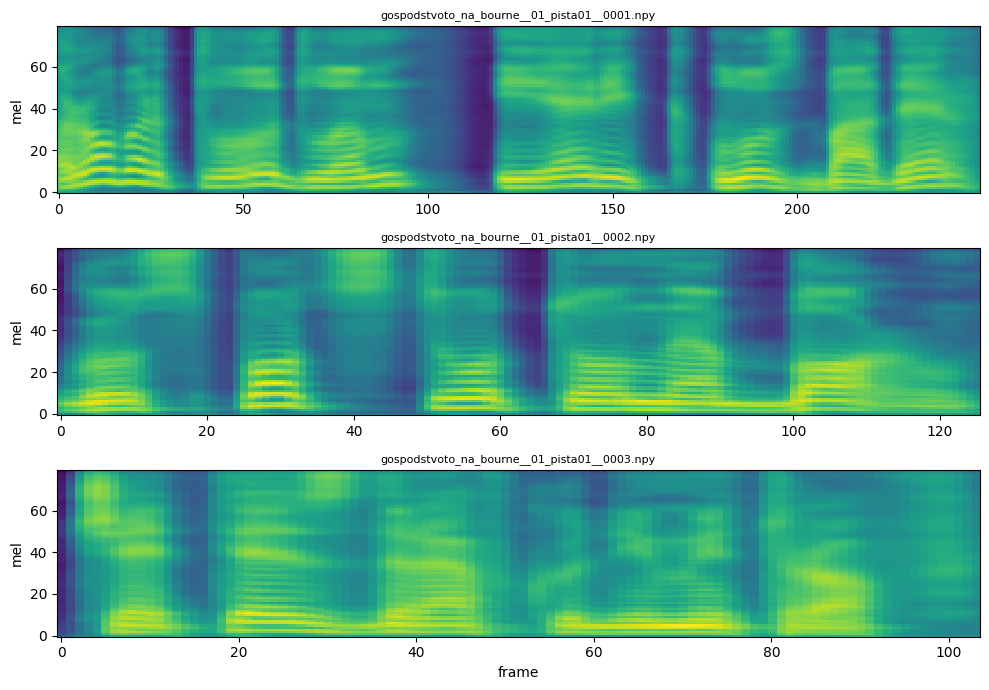

In [11]:
import numpy as np, glob, os
import matplotlib.pyplot as plt

GTA   = "/content/FastSpeech2/gta_mels/Bulgarian"
files = sorted(glob.glob(f"{GTA}/*.npy"))
print("total GTA mels:", len(files))

# numeric sanity over a sample
sample = files[:300]
shapes = [np.load(f).shape for f in sample]
m0 = np.load(files[0])
print("example:", os.path.basename(files[0]))
print("  shape:", m0.shape, " (expect [80, T])   dtype:", m0.dtype)
print("  values: min %.2f  max %.2f  mean %.2f" % (m0.min(), m0.max(), m0.mean()))
print("  all 80 mel bins:", all(s[0] == 80 for s in shapes))
print("  frame lengths T: min %d  max %d" % (min(s[1] for s in shapes), max(s[1] for s in shapes)))

# visual: a few spectrograms
fig, axes = plt.subplots(3, 1, figsize=(10, 7))
for ax, f in zip(axes, files[:3]):
    m = np.load(f)
    im = ax.imshow(m, origin="lower", aspect="auto", interpolation="none")
    ax.set_title(os.path.basename(f), fontsize=8); ax.set_ylabel("mel")
axes[-1].set_xlabel("frame")
plt.tight_layout(); plt.show()

Audio Gen

In [12]:
import os, glob, yaml, torch, numpy as np
from IPython.display import Audio, display
from scipy.io import wavfile

os.chdir("/content/FastSpeech2")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# the bundled generator ships zipped; get_vocoder loads the unzipped file
if not os.path.exists("hifigan/generator_universal.pth.tar"):
    os.system("unzip -o -q hifigan/generator_universal.pth.tar.zip -d hifigan/")

preprocess_config = yaml.load(open("config/Bulgarian/preprocess.yaml"), Loader=yaml.FullLoader)
model_config      = yaml.load(open("config/Bulgarian/model.yaml"),      Loader=yaml.FullLoader)
sr = preprocess_config["preprocessing"]["audio"]["sampling_rate"]

from utils.model import get_vocoder, vocoder_infer
vocoder = get_vocoder(model_config, device)   # HiFi-GAN universal, per model.yaml

def real_wav(utt_id):
    hits = glob.glob(f"/content/data/raw/**/{utt_id}.wav", recursive=True)
    return hits[0] if hits else None

for f in sorted(glob.glob("gta_mels/Bulgarian/*.npy"))[:3]:
    utt = os.path.splitext(os.path.basename(f))[0]
    mel = torch.from_numpy(np.load(f)).float().unsqueeze(0).to(device)      # [1, 80, T]
    wav = vocoder_infer(mel, vocoder, model_config, preprocess_config)[0]   # int16 @ sr

    print(f"=== {utt}  ({wav.shape[0]/sr:.2f}s) ===")
    print("vocoder( FS2 predicted mel )  <- this is the baseline the finetune improves")
    display(Audio(wav, rate=sr))

    rw = real_wav(utt)
    if rw:
        print("original recording  <- target")
        _sr, data = wavfile.read(rw)
        display(Audio(data, rate=_sr))

/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Removing weight norm...
=== gospodstvoto_na_bourne__01_pista01__0001  (2.90s) ===
vocoder( FS2 predicted mel )  <- this is the baseline the finetune improves


=== gospodstvoto_na_bourne__01_pista01__0002  (1.46s) ===
vocoder( FS2 predicted mel )  <- this is the baseline the finetune improves


=== gospodstvoto_na_bourne__01_pista01__0003  (1.21s) ===
vocoder( FS2 predicted mel )  <- this is the baseline the finetune improves
